# Household Financial Security Sentiment in the Ottawa/Gatineau Region

This project looks at the survey response from households in the Ottawa/Gatineau Region in regards to a specific question posted in various surveys from the government of Canada. Respondents were asked:
<br><b>"In the past 12 months, how difficult or easy was it for your household to meet its financial needs in terms of transportation, housing, food, clothing, and other necessary expenses?"</b>
* Very difficult
* Difficult
* Neither difficult nor easy
* Easy
* Very easy

This is part of the 'Making ends meet' indicator from the Government of Canada and is measured in selected iterations of the Canadian Social Survey (CSS), the Survey Series on People and their Communities (SSPC), the Survey Series on First Nations People, Métis and Inuit (SSFNPMI) and in the Canadian Housing Survey (CHS).

This data currently covers 2021-2024 and was obtained from OpenOttawa, who made it available through a custom data request to Statistics Canada.

<b>**Note on Data Quality</b>: 
Data quality assessments are conducted by Statistics Canada prior to releasing custom tabulations. This dataset contain data entries with the following advisory warning:'Please use estimate with caution and refer to the confidence interval to assess its quality.'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv('Financial_security.csv').convert_dtypes()
display(df.info())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year_Année                        384 non-null    Int64  
 1   Region_Région                     384 non-null    string 
 2   Question                          384 non-null    string 
 3   Response_Réponse                  384 non-null    string 
 4   Group_Groupe                      384 non-null    string 
 5   Subgroup_Sous_groupe              384 non-null    string 
 6   Percent_Pourcent                  384 non-null    Float64
 7   F95lcl                            384 non-null    Float64
 8   F95ucl                            384 non-null    Float64
 9   Data_quality_Qualité_des_données  96 non-null     string 
 10  Notes_Remarques                   96 non-null     string 
 11  Language_Langue                   384 non-null    string 
 12  ObjectId

None

,Year_Année,Region_Région,Question,Response_Réponse,Group_Groupe,Subgroup_Sous_groupe,Percent_Pourcent,F95lcl,F95ucl,Data_quality_Qualité_des_données,Notes_Remarques,Language_Langue,ObjectId
0,2023,Ottawa-Gatineau- Ontario part- Ontario/Quebec,In the past 12 months- how difficult or easy w...,(2) Neither difficult nor easy,15 to 34 years old,Age,37.7,28.6,47.7,<NA>,<NA>,English,1
1,2024,Ottawa-Gatineau- partie ontarienne- Ontario/Qu...,Au cours des 12 derniers mois- dans quelle mes...,(2) Ni difficile ni facile,15 à 34 ans,Âge,34.7,25.3,45.4,E,Utiliser les estimations avec précaution; réfè...,Français,2
2,2021,Ottawa-Gatineau- Ontario part- Ontario/Quebec,In the past 12 months- how difficult or easy w...,(1) Very easy or easy,35 to 44 years old,Age,50.4,38.0,62.9,E,Please use estimate with caution and refer to ...,English,3
3,2022,Ottawa-Gatineau- partie ontarienne- Ontario/Qu...,Au cours des 12 derniers mois- dans quelle mes...,(1) Très facile ou facile,35 à 44 ans,Âge,33.7,24.6,44.2,E,Utiliser les estimations avec précaution; réfè...,Français,4
4,2024,Ottawa-Gatineau- Ontario part- Ontario/Quebec,In the past 12 months- how difficult or easy w...,(2) Neither difficult nor easy,45 to 54 years old,Age,29.4,20.2,40.6,E,Please use estimate with caution and refer to ...,English,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,2024,Ottawa-Gatineau- partie ontarienne- Ontario/Qu...,Au cours des 12 derniers mois- dans quelle mes...,(2) Ni difficile ni facile,Femmes+,Genre,34.2,28.0,41.1,<NA>,<NA>,Français,380
380,2024,Ottawa-Gatineau- partie ontarienne- Ontario/Qu...,Au cours des 12 derniers mois- dans quelle mes...,(3) Très difficile ou difficile,Femmes+,Genre,29.3,23.3,36.1,<NA>,<NA>,Français,381
381,2022,Ottawa-Gatineau- partie ontarienne- Ontario/Qu...,Au cours des 12 derniers mois- dans quelle mes...,(3) Très difficile ou difficile,Femmes+,Genre,26.6,19.9,34.6,<NA>,<NA>,Français,382
382,2021,Ottawa-Gatineau- partie ontarienne- Ontario/Qu...,Au cours des 12 derniers mois- dans quelle mes...,(2) Ni difficile ni facile,Femmes+,Genre,30.9,24.1,38.6,<NA>,<NA>,Français,383


## Examining the Data
The dataset is a csv file with 13 columns that outlined what percentage of each group responded to each of the categories on the survey question. I filtered out to only see the results in English. There are 16 group types in total and I decided to focus on a set of them to see what financial security sentiments are like between the age groups, gender, racialized vs non racialized, and education level.

In [2]:
fs_df=df.drop(columns=['ObjectId','Question','Region_Région','Notes_Remarques'])
fs_df=fs_df[(fs_df['Language_Langue']=='English')]

print(fs_df['Group_Groupe'].unique())

<StringArray>
[                                              '15 to 34 years old',
                                               '35 to 44 years old',
                                               '45 to 54 years old',
                                               '55 to 64 years old',
                                               '65 years and older',
                                                      'All persons',
                                                "Bachelor's degree",
                                     'High school diploma or below',
                                                             'Men+',
                                                   'Not racialized',
     'Persons with a disability- difficulty or long-term condition',
  'Persons without a disability- difficulty or long-term condition',
 "Post-secondary certificate or diploma below the bachelor's level",
                                                       'Racialized',
                    

### Concerns on 2021 data
As you can see below, there is 24 warnings for data records in 2021 alone which means we have to take the results of that year with a grain of salt knowing it may not be accurate. When you look at the confidence levels (F95lcl & F95ucl) there are large ranges between the lower and upper confidence meaning the percentage value of that group could be actually higher or lower than listed. I could have chosen to leave 2021 out entirely, but since there is limited data covering less than 5 years, I chose to keep it.

In [3]:
groupedCautions=fs_df.groupby('Year_Année')['Data_quality_Qualité_des_données'].count()
print(groupedCautions)

cautionsIn2021=fs_df[(fs_df['Year_Année']==2021) & (fs_df['Data_quality_Qualité_des_données']=='E')]
cautionsIn2021=cautionsIn2021.drop(columns=['Subgroup_Sous_groupe','Language_Langue','Data_quality_Qualité_des_données'])

display(cautionsIn2021)

Year_Année
2021    24
2022     9
2023     6
2024     9
Name: Data_quality_Qualité_des_données, dtype: int64


,Year_Année,Response_Réponse,Group_Groupe,Percent_Pourcent,F95lcl,F95ucl
2,2021,(1) Very easy or easy,35 to 44 years old,50.4,38.0,62.9
6,2021,(1) Very easy or easy,55 to 64 years old,63.8,52.8,73.5
33,2021,(1) Very easy or easy,15 to 34 years old,43.0,33.2,53.4
36,2021,(2) Neither difficult nor easy,15 to 34 years old,39.6,29.5,50.5
37,2021,(3) Very difficult or difficult,15 to 34 years old,17.4,10.2,28.0
57,2021,(3) Very difficult or difficult,35 to 44 years old,19.2,11.7,30.1
62,2021,(2) Neither difficult nor easy,35 to 44 years old,30.3,19.4,44.0
76,2021,(2) Neither difficult nor easy,45 to 54 years old,31.7,21.9,43.5
81,2021,(1) Very easy or easy,45 to 54 years old,47.0,36.1,58.2
86,2021,(3) Very difficult or difficult,45 to 54 years old,21.3,12.5,33.8


## Examining 'All Persons' Financial Sentiment Across Years
Before drilling down into each group, let's examine the overall sentiment using the category 'All Persons'. In the graphs below, we can look at the percentage of people that selected each survey choice over the span of 2021-2024.

For 2021 results, we have to be wary of data accuracy but overall we can see a trend that is happening in each selection.
For 'Very Easy or Easy to Meet', there was a drop in the percentage of households in 2023 that selected this option, but the average between 2022-2024 sits around 34-39%. It's also interesting to note that when compared to the other choices, the highest percentage of households are indicating that it's 'Very Easy or Easy to Meet' their financial needs.

On the flipside, the 'Very Difficult or Difficult' choice is growing in the percentage of households selecting this option. 

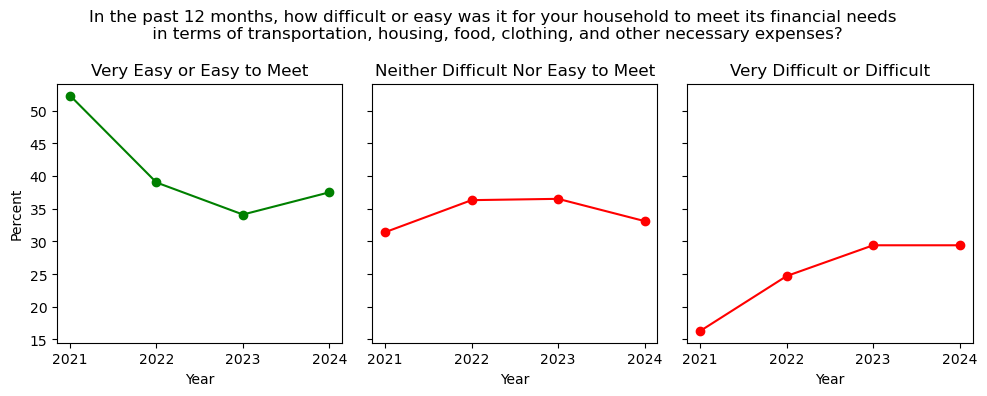

In [4]:
years=sorted(fs_df['Year_Année'].unique())
#data for All Persons
veasy_allp= fs_df[(fs_df['Response_Réponse']=='(1) Very easy or easy') & (fs_df['Group_Groupe']=='All persons')].sort_values(by='Year_Année')
veasy_allp_y=list(veasy_allp['Percent_Pourcent'])

neasy_allp= fs_df[(fs_df['Response_Réponse']=='(2) Neither difficult nor easy') & (fs_df['Group_Groupe']=='All persons')].sort_values(by='Year_Année')
neasy_allp_y=list(neasy_allp['Percent_Pourcent'])

vdifficult_allp= fs_df[(fs_df['Response_Réponse']=='(3) Very difficult or difficult') & (fs_df['Group_Groupe']=='All persons')].sort_values(by='Year_Année')
vdifficult_allp_y=list(vdifficult_allp['Percent_Pourcent'])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 4))
plt.xticks(years)
fig.suptitle('In the past 12 months, how difficult or easy was it for your household to meet its financial needs \n in terms of transportation, housing, food, clothing, and other necessary expenses?')

ax1.plot(years, veasy_allp_y, 'go-')
ax1.set_title('Very Easy or Easy to Meet')
ax1.set_xlabel('Year')
ax1.set_ylabel('Percent')

ax2.plot(years, neasy_allp_y, 'ro-') 
ax2.set_title('Neither Difficult Nor Easy to Meet')
ax2.set_xlabel('Year')
# ax2.set_ylabel('Percent')

ax3.plot(years, vdifficult_allp_y, 'ro-') 
ax3.set_title('Very Difficult or Difficult')
ax3.set_xlabel('Year')
# ax3.set_ylabel('Percent')

plt.tight_layout()
plt.show()


## Examining Financial Security Sentiment Between Age Groups

Diving deeper into the data, we want to see 'who' is indicating that it's easy to meet their household needs versus who is finding that it's becoming more difficult. To do so, I've set up a series of pie charts to examine the percentage of each age groups that have selected these options and how it may have changed over the years.

### Percentage of Age Groups that Feel They Meet Financial Needs Easily 

Consistenly across all 4 years, the age group that found it most easy to meet their financial needs are those 65 years and older. This is then followed by the 55 to 64 years age group, though not as strongly consistent.

The lowest percent age group that selected this choice for multiple years is 35 to 44 years old.

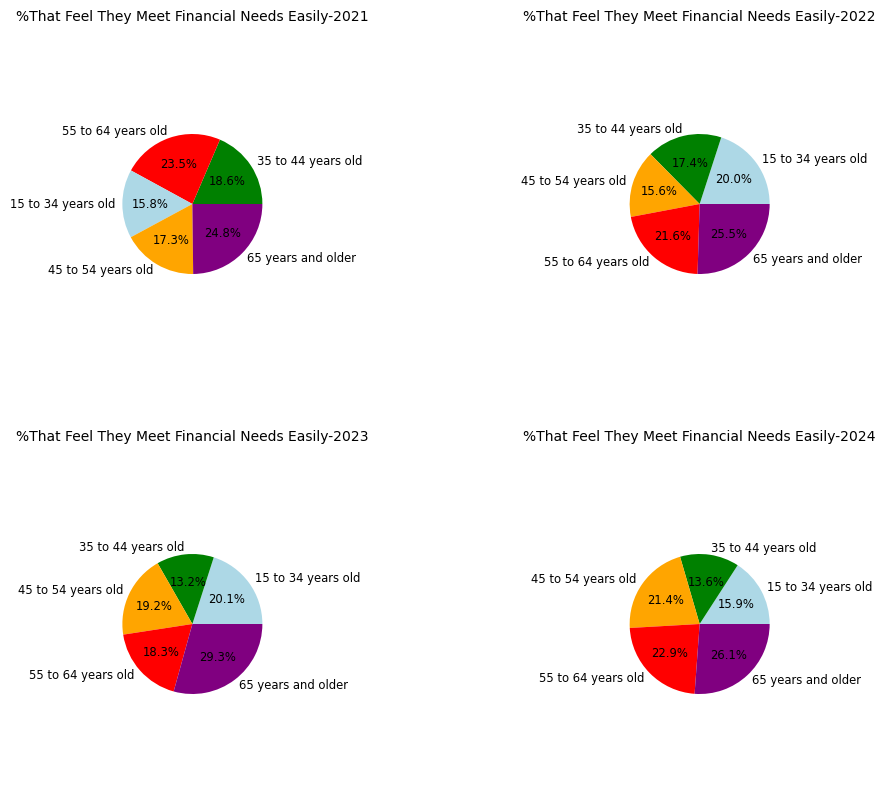

In [5]:
ageGroupsEasy={}
ageGroupsNeither={}
ageGroupsDifficult={}

for y in years:
    ageGroupsEasy[y]=fs_df[(fs_df['Response_Réponse']=='(1) Very easy or easy') & (fs_df['Subgroup_Sous_groupe']=='Age') & (fs_df['Year_Année']==y)]
    ageGroupsNeither[y]=fs_df[(fs_df['Response_Réponse']=='(2) Neither difficult nor easy') & (fs_df['Subgroup_Sous_groupe']=='Age') & (fs_df['Year_Année']==y)]
    ageGroupsDifficult[y]=fs_df[(fs_df['Response_Réponse']=='(3) Very difficult or difficult') & (fs_df['Subgroup_Sous_groupe']=='Age') & (fs_df['Year_Année']==y)]

color_map = {
    '15 to 34 years old': 'lightblue', 
    '35 to 44 years old': 'green', 
    '45 to 54 years old': 'orange', 
    '55 to 64 years old': 'red',
    '65 years and older': 'purple'
}

fig, plots = plt.subplots(2, 2, sharex=True, figsize=(12, 10))
plot_axis=plots.flatten()

for y, pl in zip(years,plot_axis):
    easyData=ageGroupsEasy[y]
    current_colors = [color_map[label] for label in easyData['Group_Groupe']]
    
    pl.pie(easyData['Percent_Pourcent'], labels=easyData['Group_Groupe'], autopct='%1.1f%%', colors=current_colors, textprops={'size': 'smaller'}, radius=0.5)
    pl.set_title(f'%That Feel They Meet Financial Needs Easily-{y}', fontsize=10)
        
plt.show()

### Percentage of Age Groups that Feel They Meet Financial Needs Neither Easily nor Hard

There are slight flunctuations that occur in the percentage of each age group that selected this option, where they will go up and down between the years, but overall there are no dramatic increases/decreases for a specific age groupmaking it feel more neutral.

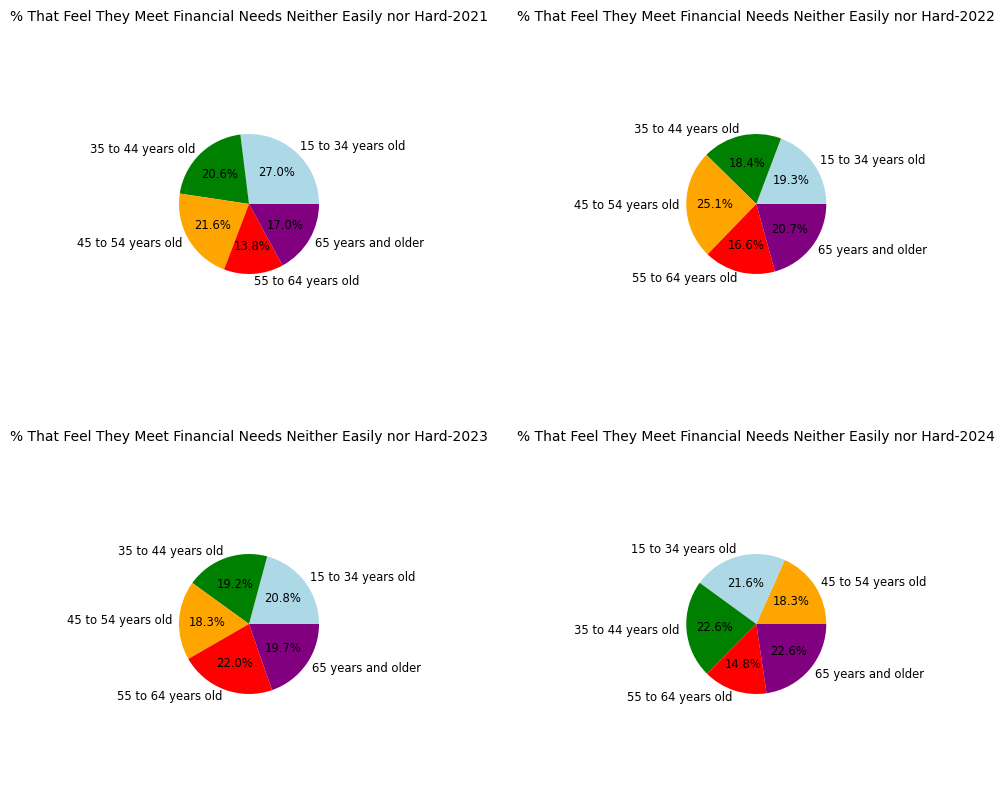

In [6]:
fig, plots = plt.subplots(2, 2, sharex=True, figsize=(12, 10))
plot_axis=plots.flatten()


for y, pl in zip(years,plot_axis):
    neitherData=ageGroupsNeither[y]
    current_colors = [color_map[label] for label in neitherData['Group_Groupe']]
    pl.pie(neitherData['Percent_Pourcent'], labels=neitherData['Group_Groupe'], autopct='%1.1f%%', colors=current_colors, textprops={'size': 'smaller'}, radius=0.5)
    pl.set_title(f'% That Feel They Meet Financial Needs Neither Easily nor Hard-{y}', fontsize=10)
        
plt.show()

### Percentage of Age Groups that Feel They Meet Financial Needs with Difficulty

The age group that selected this sentiment the most and consistently across the 4 years are those 35 to 44 years old. The 65 years and older group and the 55 to 64 years old group see the least amount of percentage change throughout the years. 

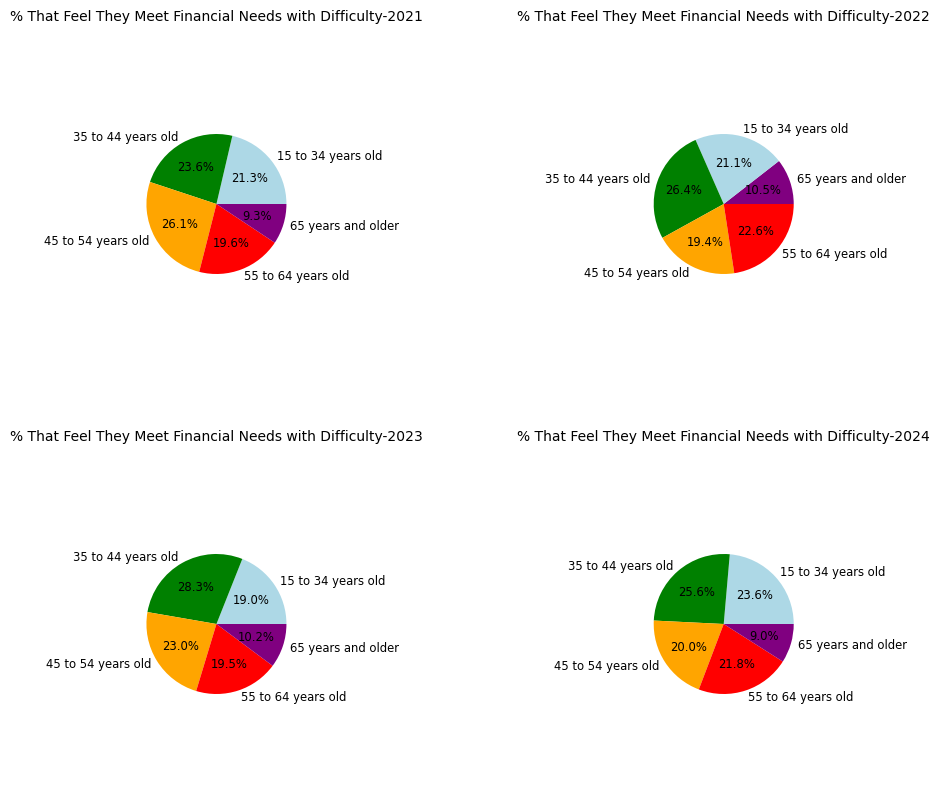

In [7]:
fig, plots = plt.subplots(2, 2, sharex=True, figsize=(12, 10))
plot_axis=plots.flatten()

for y, pl in zip(years,plot_axis):
    difficultData=ageGroupsDifficult[y]
    current_colors = [color_map[label] for label in difficultData['Group_Groupe']]
    pl.pie(difficultData['Percent_Pourcent'], labels=difficultData['Group_Groupe'], autopct='%1.1f%%', colors=current_colors, textprops={'size': 'smaller'}, radius=0.5)
    pl.set_title(f'% That Feel They Meet Financial Needs with Difficulty-{y}', fontsize=10)
        
plt.show()

## Examining Financial Security Sentiment Between Genders

Next we'll look at the sentiment between genders indicated as 'Women+' and 'Men+'. It's important to highlight that the percentage of both gender categories added up will not equal 100%, as it may not include any other gender types that could have been indicated by the respondents under the survey option 'Or please specify' when asked 'What is your gender?'

On an overview level, Women+ have consistently found it more difficult to meet financial needs compared to Men+ over the years. However, there is an upward trend in the increasing percentage of Men+ that are finding it 'Very Difficult or Difficult' as well, with an interesting observation that both gender categories started to converge at 2024.

However, for both gender categories especially with Men+, a majority percentage of them indicate it's 'Very Easy or Easy' for their household to meet its financial needs compared to the percentage that responded with the other options.


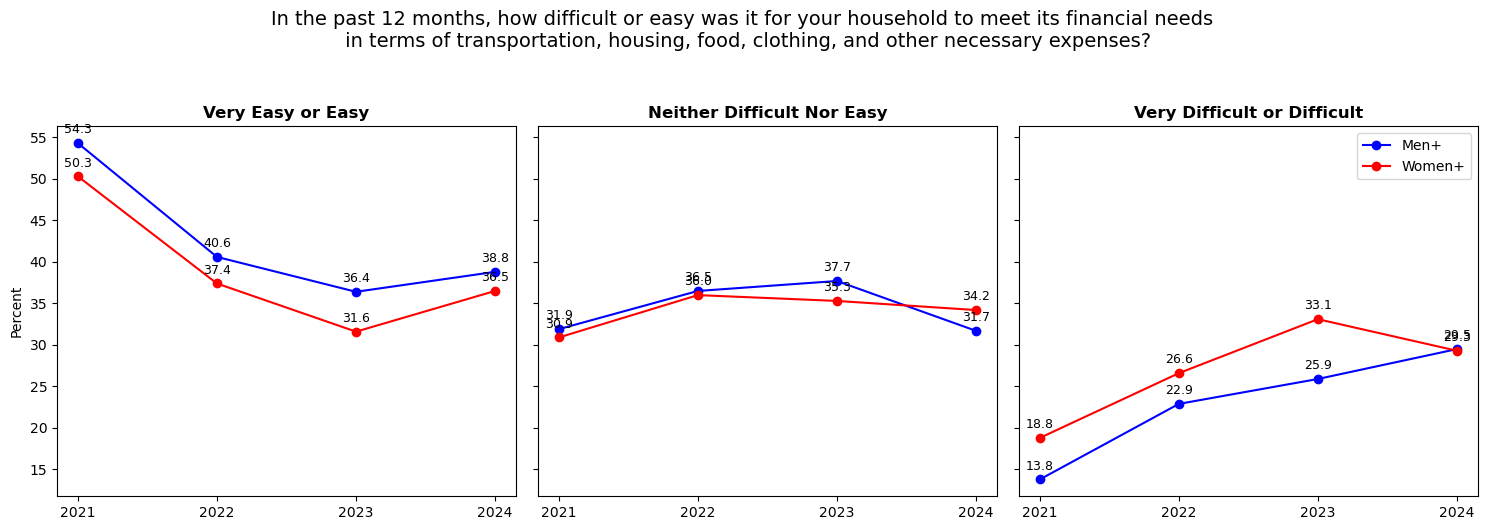

In [8]:
genders={'Women+', 'Men+'}
colors = {'Women+':'red', 'Men+':'blue'}
categories = [
    '(1) Very easy or easy', 
    '(2) Neither difficult nor easy', 
    '(3) Very difficult or difficult'
]
titles=['Very Easy or Easy', 'Neither Difficult Nor Easy', 'Very Difficult or Difficult']

df_plot = fs_df.pivot_table(
    index=['Group_Groupe', 'Response_Réponse'], 
    columns='Year_Année', 
    values='Percent_Pourcent'
)

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(15, 5))

for i, cat in enumerate(categories):
    ax = axs[i]
    
    for g in genders:
        data = df_plot.loc[(g, cat)]
        line = ax.plot(years, data, label=g, color=colors[g], marker='o')
        
        for x, y in zip(years, data):
            ax.annotate(f'{y}', xy=(x, y), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=9)

    ax.set_title(titles[i], fontweight='bold')
    ax.set_xticks(years)
    if i == 0: ax.set_ylabel('Percent')

axs[2].legend()
fig.suptitle('In the past 12 months, how difficult or easy was it for your household to meet its financial needs \n in terms of transportation, housing, food, clothing, and other necessary expenses?', 
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## Financial Security Sentiment Based on Education Level

Next up we'll see the breakdown percentage of respondants that selected each survey option according to their education level. There are 4 summarized categories that are based on the highest certificate, diploma or degree that the respondant had completed:
*  University above bachelor's level
*  Post-secondary certificate or diploma below the bachelor's level
*  High school diploma or below
*  Bachelor's degree

### % That Feel They Meet Financial Needs Easily - Education

For those that completed university above a bachelor's level, the percentage of them finding it easy to meet their financial needs has been decreasing over the 4 years, where by 2024 the percentage is the same as those who have just a bachelor's degree.

For majority of the years, the group with the smallest percentage of respondants that feel they meet financial needs easily are those that only have a post-secondary certificate or diploma below the bachelor's level.

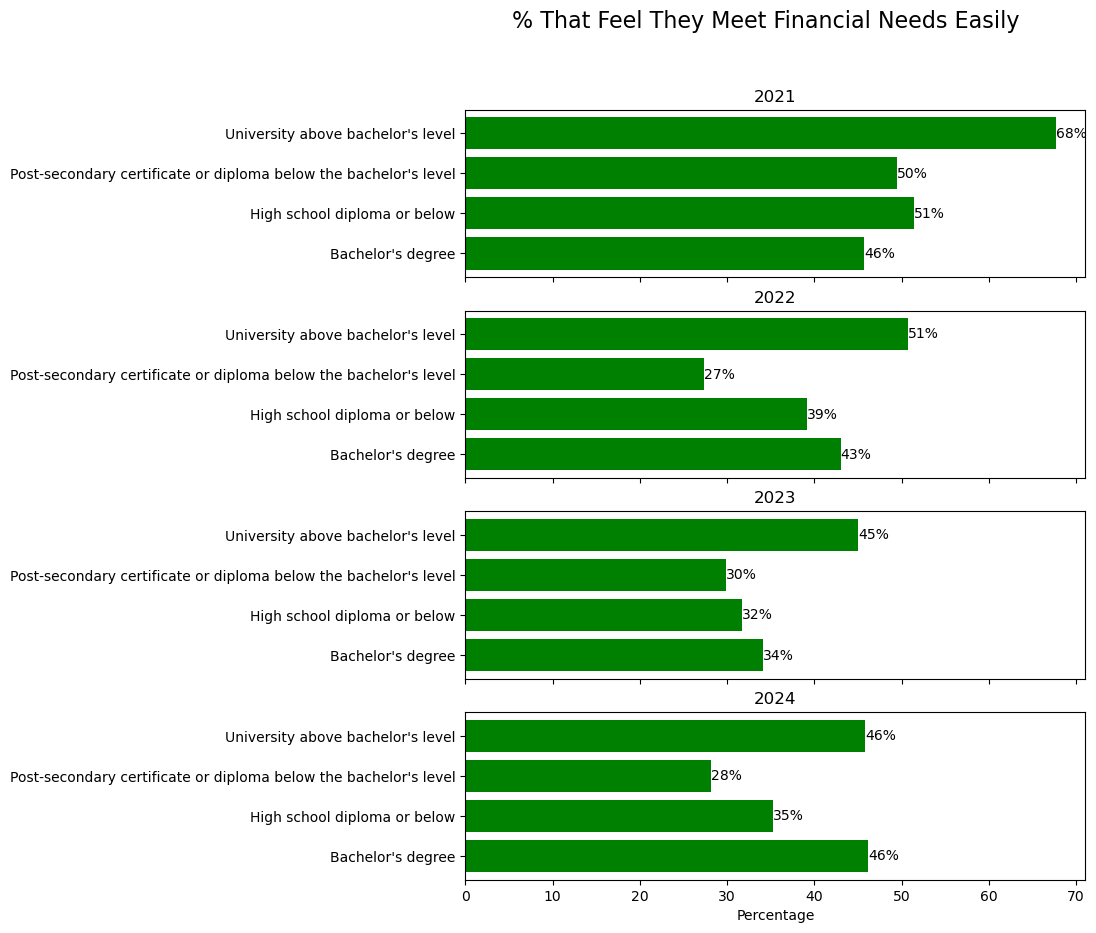

In [9]:
education_df=fs_df[(fs_df['Subgroup_Sous_groupe']=="Education level")]

educationGroupsEasy={}
educationGroupsNeither={}
educationGroupsDifficult={}

for y in years:
    educationGroupsEasy[y]=education_df[(education_df['Response_Réponse']=='(1) Very easy or easy') & (education_df['Year_Année']==y)].sort_values(by='Year_Année')
    educationGroupsNeither[y]=education_df[(education_df['Response_Réponse']=='(2) Neither difficult nor easy') & (education_df['Year_Année']==y)].sort_values(by='Year_Année')
    educationGroupsDifficult[y]=education_df[(education_df['Response_Réponse']=='(3) Very difficult or difficult') & (education_df['Year_Année']==y)].sort_values(by='Year_Année')

fig, axs =plt.subplots(4, 1, sharex=True, figsize=(8, 10))
bar_axis= axs.flatten()

for y, ax in zip(years, bar_axis): 
    eduGroupEasy=educationGroupsEasy[y].sort_values(by='Group_Groupe')
    # print(eduGroupEasy)
    bars=ax.barh(eduGroupEasy['Group_Groupe'],eduGroupEasy['Percent_Pourcent'], color='green')
    ax.set_title(y)
    ax.bar_label(bars,fmt='%.0f%%',label_type='edge')
    
fig.suptitle('% That Feel They Meet Financial Needs Easily', fontsize=16)
ax.set_xlabel('Percentage')

plt.show()

### % That Feel They Meet Financial Needs Neither Easily nor with Difficulty - Education

In 2021 and 2022, there were distinguishable differences in the percentages between the different levels of education, though starting in 2023 the gap between the levels had started closing and by 2024 they now all fall within a 31-35% range. It appears that there weren't any large percentage of a specific group based on educational level that held this sentiment more than others. 

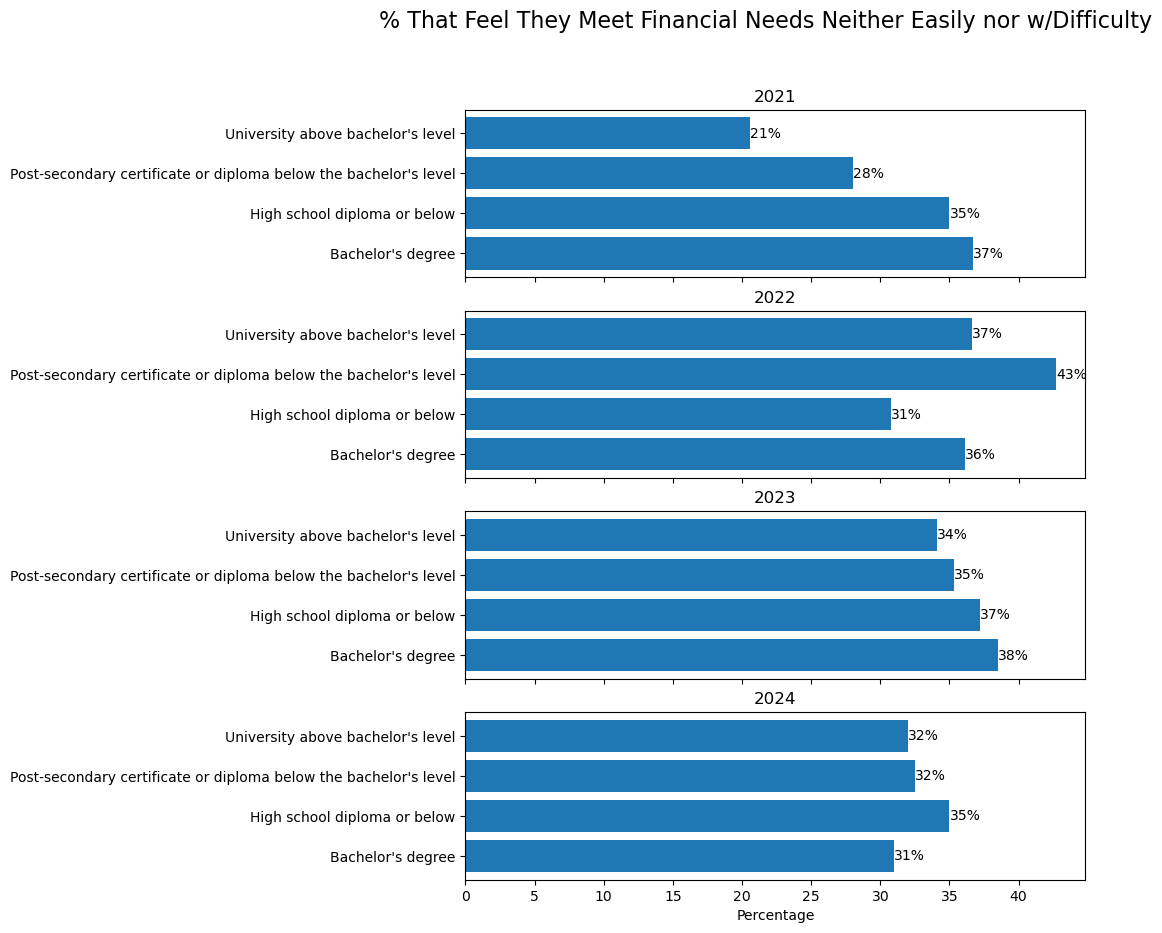

In [10]:
fig, axs =plt.subplots(4, 1, sharex=True, figsize=(8, 10))
bar_axis= axs.flatten()

for y, ax in zip(years, bar_axis): 
    eduGroupNeither=educationGroupsNeither[y].sort_values(by='Group_Groupe')
    bars=ax.barh(eduGroupNeither['Group_Groupe'],eduGroupNeither['Percent_Pourcent'])
    ax.set_title(y)
    ax.bar_label(bars,fmt='%.0f%%',label_type='edge')
    
fig.suptitle('% That Feel They Meet Financial Needs Neither Easily nor w/Difficulty', fontsize=16)
ax.set_xlabel('Percentage')

plt.show()

### % That Feel They Meet Financial Needs with Difficulty

From 2021 to 2024, all groups saw a degree of increase in the percentage of respondants indicating that they feel they meet financial needs with difficulty. The largest increase in percentage was seen in those with a Post-Secondary certificate or diploma below the bachelor's level, with 40% of them indicating difficulty in 2024.

The group with an educational level above a bachelor's level saw a large jump from 2022 to 2023, going up 8% in the percentage of respondents, while the percentage of people with high school diploma or below feeling financial difficulty remains relatively the same from 2022-2024.

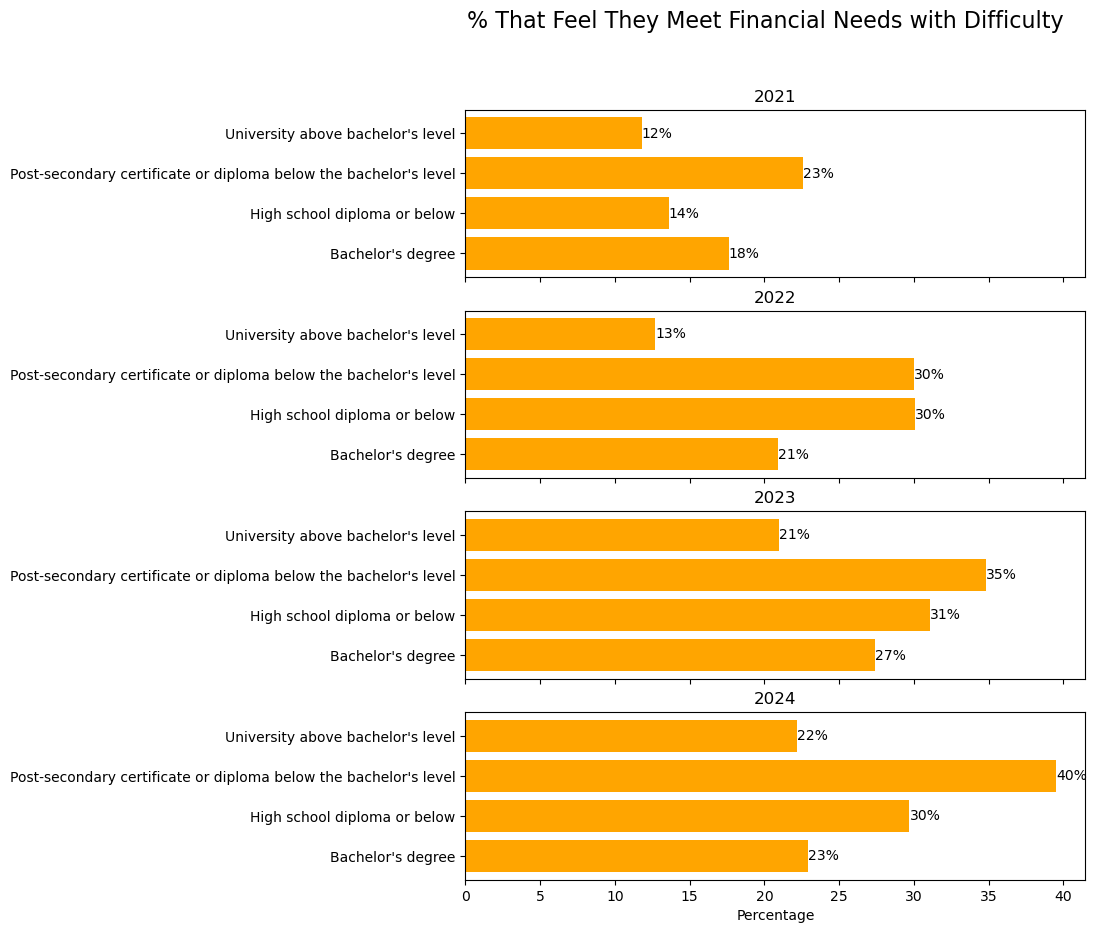

In [11]:
fig, axs =plt.subplots(4, 1, sharex=True, figsize=(8, 10))
bar_axis= axs.flatten()

for y, ax in zip(years, bar_axis): 
    eduGroupDiff=educationGroupsDifficult[y].sort_values(by='Group_Groupe')
    bars=ax.barh(eduGroupDiff['Group_Groupe'],eduGroupDiff['Percent_Pourcent'], color='orange')
    ax.set_title(y)
    ax.bar_label(bars,fmt='%.0f%%',label_type='edge')
    
fig.suptitle('% That Feel They Meet Financial Needs with Difficulty', fontsize=16)
ax.set_xlabel('Percentage')

plt.show()

## Meeting Financial Needs for those Racialized vs Not Racilaized

Finally, the last group category we'll take a look at is those who are racialized (visible minority) compared to those who are not and see what the differences may be between these groups in their sense of financial security.

Those that find it 'Very easy or easy' to meet financial needs are predominantly Not Racialized; this is 38-45% from 2022-2024 compared to 23-26% of Racialized respondents feeling the same. Contrastly, those that found it neither easy nor difficulty or very difficult were predominantly racialized, though it's of interest to note how percentage of both groups are starting to overlap in feeling 'very difficult/difficult' in 2024. 

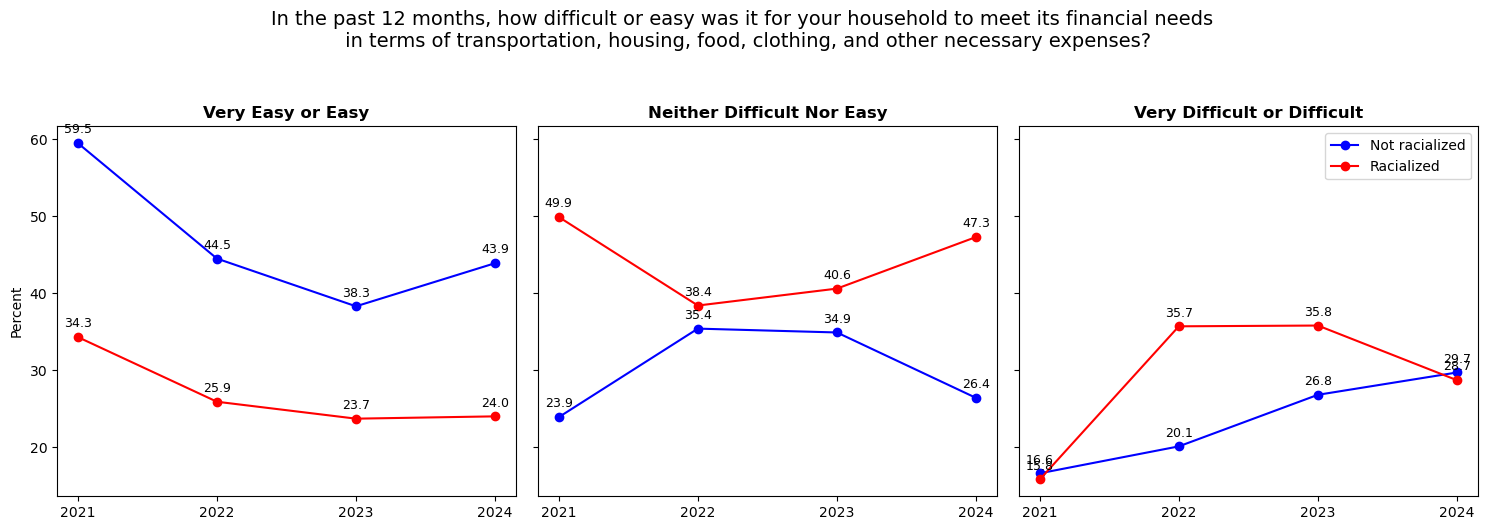

In [12]:
rGroup={'Racialized', "Not racialized"}
colours= {'Racialized':'red',"Not racialized":'blue'}
categories = [
    '(1) Very easy or easy', 
    '(2) Neither difficult nor easy', 
    '(3) Very difficult or difficult'
]
titles=['Very Easy or Easy', 'Neither Difficult Nor Easy', 'Very Difficult or Difficult']

df_plot = fs_df.pivot_table(
    index=['Group_Groupe','Response_Réponse'],
    columns='Year_Année',
    values='Percent_Pourcent'
)
# print(df_plot)

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(15, 5))

for i, cat in enumerate(categories):
    ax = axs[i]
    
    for g in rGroup:
        data=df_plot.loc[(g,cat)]
        line=ax.plot(years, data, label=g, color=colours[g], marker='o',)

        for x, y, in zip(years, data):
            ax.annotate(f'{y}', xy=(x,y), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=9) 
        
    ax.set_title(titles[i], fontweight='bold')
    ax.set_xticks(years)
    if i == 0: ax.set_ylabel('Percent')

axs[2].legend()
fig.suptitle('In the past 12 months, how difficult or easy was it for your household to meet its financial needs \n in terms of transportation, housing, food, clothing, and other necessary expenses?', 
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## Conclusion

Summarizing the findings, there are some areas of note when examining the characteristics of respondents against the response option they chose when answering the survey question: 
"In the past 12 months, how difficult or easy was it for your household to meet its financial needs in terms of transportation, housing, food, clothing, and other necessary expenses?"

Those that answered 'Very Easy or Easy' were likely to be at least one of these categories:
* 65 years and older
* Male+
* Not Racialized
* Educational level obtained is Bachelor's or Above

Those that answered 'Very Difficult or Difficult' were likely to be at least one of these categories:
* 35 to 44 years old
* Women+
* Racialized
* Educational level obtained is Post-Secondary certificate or diploma below the bachelor's level, or High School Diploma

Though the majority percentage of respondants in total indicate that it's very easy/easy for their household to meet its financial needs, there was a  approximate 13% drop from 2021 to 2022 and another drop in 2023 before it saw a slight increase in 2024. As for the percentage of respondents that indicate it was very difficult/difficult, there's been an upward trend from 2021. This implies that after 2021, more households were finding it to be difficult to meet their financial needs or no longer found it as easy compared to previous years.

For the 65 years and older age group, this was the group with the highest percentage of respondents that found it easy to meet financial needs. I personally speculate that this is a group that's most likely to be retired and may have had years to accumulate wealth to support their current lifestyles. Their houses and cards could also potentially be paid off at this point, thus reducing a large part of reoccurring debt. 

Those that fall in the Women+ category made up a larger percentage of respondents that found it financially difficult in comparison to Men+, though it is interesting to note that by 2024, both groups were close to being the same percentage size. This similar overlap also occurred when examining racialized and not racialized groups. Though there was a gap between the two groups in 2022 and 2023, by 2024 both groups had similar percentages of respondents finding that it was financially difficult for them. The trend can be interpreted as households in total feeling more financially strained regardless of gender or racial background.

When examining education levels,the percentage of those that had a university education above a bachelor's level started becoming on par with those with a bachelor's degree in terms of respondents feeling that it was less easier to meet financial needs over the years. Despite having an education higher than a bachelor's, it does not seem like it made meeting financial needs any easier. However, for those that only have a Post-Secondary certificate or diploma below the bachelor's level or a high school diploma, they are consistently feeling more financial difficulty than those with higher education.

Overall a majority of respondents in the Ottawa/Gatineau region find it's very easy/easy to meet their household needs. However, looking at the trend from 2021-2024, there is a growing sentiment over the years of respondents finding it less easier to meet their household needs, so this sentiment could change in the next couple of years. The percentage that answer 'neither easy nor difficult' seems to remain in a consistent range while there is a growing trend of respondents finding it to be difficult. Though Women+ and those who are racialized have been in more financial difficulty throughout the years, their counterparts are starting to bear the same sentiment implying that everyone regardless of gender and race are feeling the same financial pressure. Those that are 35 to 44 years old feel the most financial difficult, though the 45-54 year olds and 15-34 year olds follow closely behind making a population of those under 55 years old. I would be interested in seeing how this data develops over the next couple of years in a post-covid environment, along with the current rise of AI, political tensions, and job layoffs. 




